In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Amazon_Sales_Data (1).csv to Amazon_Sales_Data (1) (1).csv


In [ ]:
from google.colab import files
uploaded_excel = files.upload()

Saving excel2.csv to excel2 (1).csv


In [ ]:
import pandas as pd

In [ ]:
# Read the two CSV files
df1 = pd.read_csv("Amazon_Sales_Data (1).csv")
df2 = pd.read_csv("excel2.csv")

In [ ]:
# Merge them into one DataFrame
merged_df = pd.concat([df1, df2], ignore_index=True)

In [ ]:
# Fill missing values with the mean (numeric columns only)
merged_df = merged_df.fillna(merged_df.mean(numeric_only=True))

In [ ]:
# Save the cleaned file as Excel
merged_df.to_excel("merged_file.xlsx", index=False)

In [ ]:
# Download the resulting file
files.download("merged_file.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Data Preprocessing and Exploratory Data Analysis (EDA)

Let's start by inspecting the `merged_df` to understand its structure and data types.

In [ ]:
print("Information about merged_df:")
merged_df.info()

Information about merged_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1816 entries, 0 to 1815
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country         1810 non-null   object 
 1   Item_Type       1656 non-null   object 
 2   Order_Date      1710 non-null   object 
 3   Order_ID        1816 non-null   float64
 4   Order_Priority  1710 non-null   object 
 5   Region          1810 non-null   object 
 6   Sales_Channel   1710 non-null   object 
 7   Ship_Date       1710 non-null   object 
 8   Total_Cost      1816 non-null   float64
 9   Total_Revenue   1816 non-null   float64
 10  Units_Sold      1816 non-null   float64
 11  Item Type       100 non-null    object 
 12  Sales Channel   100 non-null    object 
 13  Order Priority  100 non-null    object 
 14  Order Date      100 non-null    object 
 15  Order ID        1816 non-null   float64
 16  Ship Date       100 non-null    object 
 17  Unit

In [ ]:
print("\nDescriptive statistics for numeric columns:")
display(merged_df.describe())


Descriptive statistics for numeric columns:


,Order_ID,Total_Cost,Total_Revenue,Units_Sold,Order ID,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
count,1.816000e+03,1.816000e+03,1.816000e+03,1816.000000,1.816000e+03,1816.000000,1816.000000,1816.000000,1.816000e+03,1.816000e+03,1.816000e+03
mean,5.451249e+08,9.430244e+05,1.409165e+06,5317.057895,5.550204e+08,5128.710000,276.761300,191.048000,1.373488e+06,9.318057e+05,4.416820e+05
std,2.453159e+08,1.043378e+06,1.410571e+06,2742.893784,6.086661e+07,652.650984,55.022493,43.955961,3.409892e+05,2.531534e+05,1.024204e+05
min,1.146066e+08,3.612240e+03,4.870260e+03,124.000000,1.146066e+08,124.000000,9.330000,6.920000,4.870260e+03,3.612240e+03,1.258020e+03
25%,3.457186e+08,1.970483e+05,3.870022e+05,3482.000000,5.550204e+08,5128.710000,276.761300,191.048000,1.373488e+06,9.318057e+05,4.416820e+05
50%,5.451249e+08,4.489777e+05,8.023338e+05,5430.000000,5.550204e+08,5128.710000,276.761300,191.048000,1.373488e+06,9.318057e+05,4.416820e+05
75%,7.288153e+08,1.373244e+06,2.011150e+06,7450.000000,5.550204e+08,5128.710000,276.761300,191.048000,1.373488e+06,9.318057e+05,4.416820e+05
max,9.940222e+08,4.509794e+06,5.997055e+06,9925.000000,9.940222e+08,9925.000000,668.270000,524.960000,5.997055e+06,4.509794e+06,1.719922e+06


In [ ]:
print("\nNumber of unique values per column:")
display(merged_df.nunique())


Number of unique values per column:


,0
Country,78
Item_Type,12
Order_Date,100
Order_ID,101
Order_Priority,4
Region,8
Sales_Channel,2
Ship_Date,99
Total_Cost,101
Total_Revenue,101


### Consolidating Redundant Columns

We noticed several columns representing the same information but with different names (e.g., `Item_Type` and `Item Type`). Let's consolidate these to create a cleaner dataset. We'll prioritize the `df1` column names and fill any missing values from the corresponding `df2` column.

In [ ]:
# List of column pairs to consolidate (target_col, source_col)
column_pairs_to_consolidate = [
    ('Item_Type', 'Item Type'),
    ('Order_Date', 'Order Date'),
    ('Order_ID', 'Order ID'),
    ('Order_Priority', 'Order Priority'),
    ('Sales_Channel', 'Sales Channel'),
    ('Ship_Date', 'Ship Date'),
    ('Units_Sold', 'Units Sold'),
    ('Total_Cost', 'Total Cost'),
    ('Total_Revenue', 'Total Revenue')
]

for target_col, source_col in column_pairs_to_consolidate:
    if source_col in merged_df.columns:
        # Fill NaNs in the target column with values from the source column
        # Use .astype(str) for object columns to ensure consistency before fillna
        # For numeric columns, fillna directly
        if merged_df[target_col].dtype == 'object' or merged_df[source_col].dtype == 'object':
            merged_df[target_col] = merged_df[target_col].astype(str).replace('nan', pd.NA).fillna(merged_df[source_col].astype(str).replace('nan', pd.NA))
        else:
            merged_df[target_col] = merged_df[target_col].fillna(merged_df[source_col])

        # Drop the source column after consolidation
        merged_df = merged_df.drop(columns=[source_col])

# Display info again to confirm consolidation and check for remaining NaNs
print("Information about merged_df after consolidating columns:")
merged_df.info()

print("\nNumber of unique values per column after consolidating columns:")
display(merged_df.nunique())

Information about merged_df after consolidating columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1816 entries, 0 to 1815
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country         1810 non-null   object 
 1   Item_Type       1756 non-null   object 
 2   Order_Date      1810 non-null   object 
 3   Order_ID        1816 non-null   float64
 4   Order_Priority  1810 non-null   object 
 5   Region          1810 non-null   object 
 6   Sales_Channel   1810 non-null   object 
 7   Ship_Date       1810 non-null   object 
 8   Total_Cost      1816 non-null   float64
 9   Total_Revenue   1816 non-null   float64
 10  Units_Sold      1816 non-null   float64
 11  Unit Price      1816 non-null   float64
 12  Unit Cost       1816 non-null   float64
 13  Total Profit    1816 non-null   float64
dtypes: float64(7), object(7)
memory usage: 198.8+ KB

Number of unique values per column after consolidating column

,0
Country,78
Item_Type,12
Order_Date,200
Order_ID,101
Order_Priority,4
Region,8
Sales_Channel,2
Ship_Date,198
Total_Cost,101
Total_Revenue,101


### Converting Date Columns to Datetime Objects

Next, let's convert the `Order_Date` and `Ship_Date` columns to datetime objects. This will allow for easier time-based analysis.

In [ ]:
# Convert date columns to datetime objects
merged_df['Order_Date'] = pd.to_datetime(merged_df['Order_Date'], errors='coerce')
merged_df['Ship_Date'] = pd.to_datetime(merged_df['Ship_Date'], errors='coerce')

print("Information about merged_df after date conversion:")
merged_df.info()

Information about merged_df after date conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1816 entries, 0 to 1815
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country         1810 non-null   object        
 1   Item_Type       1756 non-null   object        
 2   Order_Date      1710 non-null   datetime64[ns]
 3   Order_ID        1816 non-null   float64       
 4   Order_Priority  1810 non-null   object        
 5   Region          1810 non-null   object        
 6   Sales_Channel   1810 non-null   object        
 7   Ship_Date       1710 non-null   datetime64[ns]
 8   Total_Cost      1816 non-null   float64       
 9   Total_Revenue   1816 non-null   float64       
 10  Units_Sold      1816 non-null   float64       
 11  Unit Price      1816 non-null   float64       
 12  Unit Cost       1816 non-null   float64       
 13  Total Profit    1816 non-null   float64       
dtypes: da

/tmp/ipykernel_8667/2971579372.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  merged_df['Order_Date'] = pd.to_datetime(merged_df['Order_Date'], errors='coerce')
/tmp/ipykernel_8667/2971579372.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  merged_df['Ship_Date'] = pd.to_datetime(merged_df['Ship_Date'], errors='coerce')


### Handling Remaining Missing Values

Now that columns are consolidated and dates converted, let's re-evaluate missing values, especially in categorical columns, and decide on a strategy (e.g., fill with mode or a placeholder).

In [ ]:
### Handling Remaining Missing Values

Now that columns are consolidated and dates converted, let's re-evaluate missing values, especially in categorical columns, and decide on a strategy (e.g., fill with mode or a placeholder).

SyntaxError: unterminated string literal (detected at line 3) (2561862801.py, line 3)

### Dropping Rows with Missing Dates

Given the remaining missing values in `Order_Date` and `Ship_Date` (which are `NaT` values due to unparseable dates), we will drop these rows to ensure clean date data for further analysis. We will then re-check for missing values.

In [ ]:
# Drop rows where Order_Date or Ship_Date is NaT
merged_df.dropna(subset=['Order_Date', 'Ship_Date'], inplace=True)

print("Missing values count after dropping rows with missing dates:")
print(merged_df.isnull().sum())

print("\nInformation about merged_df after dropping rows with missing dates:")
merged_df.info()

Missing values count after dropping rows with missing dates:
Country           0
Item_Type         0
Order_Date        0
Order_ID          0
Order_Priority    0
Region            0
Sales_Channel     0
Ship_Date         0
Total_Cost        0
Total_Revenue     0
Units_Sold        0
Unit Price        0
Unit Cost         0
Total Profit      0
dtype: int64

Information about merged_df after dropping rows with missing dates:
<class 'pandas.core.frame.DataFrame'>
Index: 1710 entries, 0 to 1715
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country         1710 non-null   object        
 1   Item_Type       1710 non-null   object        
 2   Order_Date      1710 non-null   datetime64[ns]
 3   Order_ID        1710 non-null   float64       
 4   Order_Priority  1710 non-null   object        
 5   Region          1710 non-null   object        
 6   Sales_Channel   1710 non-null   object        
 7   Sh

### Further Exploratory Data Analysis (EDA)

Now that our data is cleaner, with consolidated columns and handled missing values (including dates), let's proceed with more detailed EDA. We can start by examining the distribution of key numerical variables and exploring relationships between different columns.

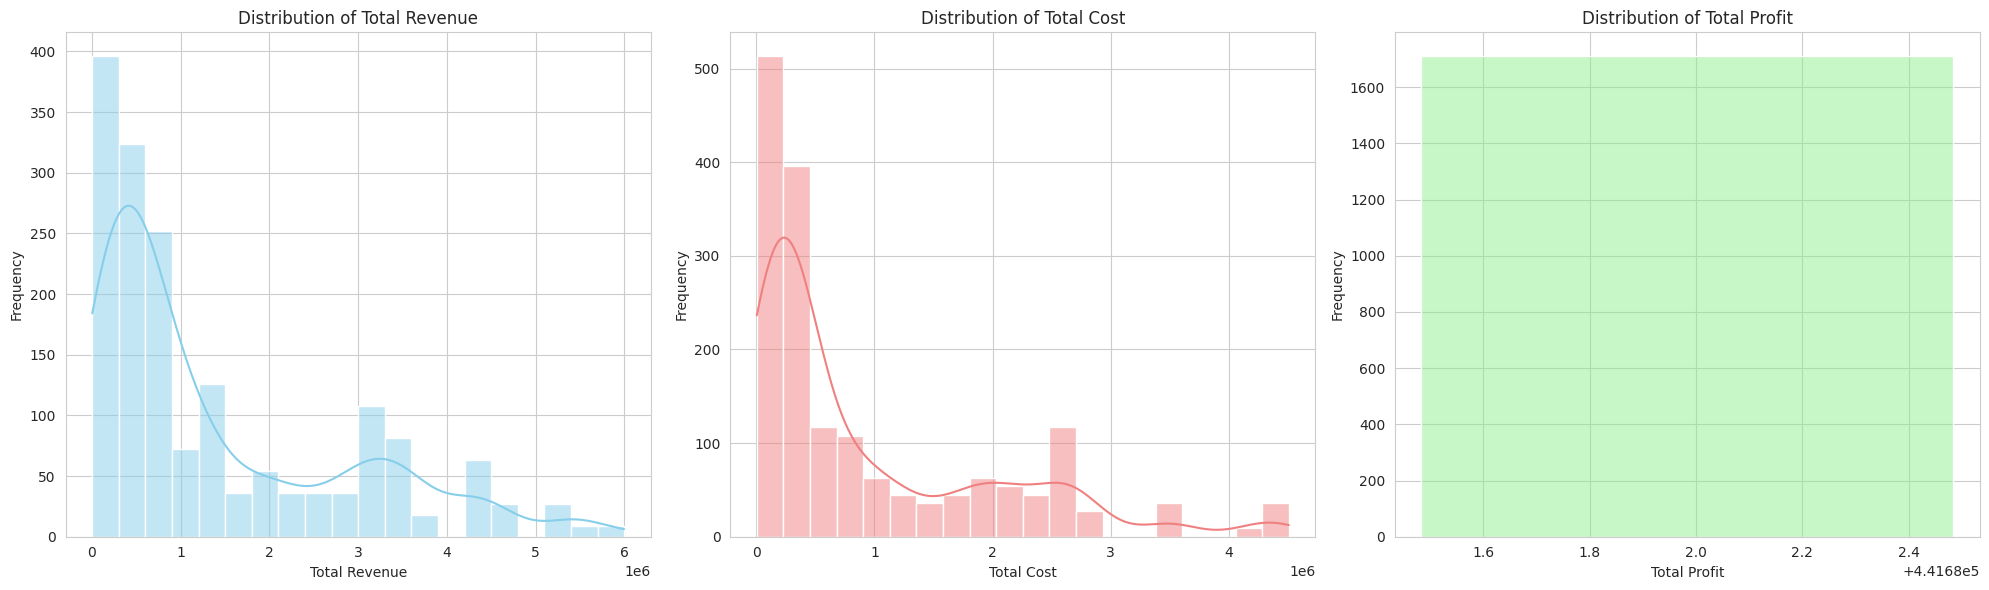

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create subplots for each histogram
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Histogram for Total_Revenue
sns.histplot(merged_df['Total_Revenue'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Total Revenue')
axes[0].set_xlabel('Total Revenue')
axes[0].set_ylabel('Frequency')

# Histogram for Total_Cost
sns.histplot(merged_df['Total_Cost'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Total Cost')
axes[1].set_xlabel('Total Cost')
axes[1].set_ylabel('Frequency')

# Histogram for Total_Profit
sns.histplot(merged_df['Total Profit'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Total Profit')
axes[2].set_xlabel('Total Profit')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# Histogram for Total_Cost
sns.histplot(merged_df['Total_Cost'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Total Cost')
axes[1].set_xlabel('Total Cost')
axes[1].set_ylabel('Frequency')


Text(688.6250000000001, 0.5, 'Frequency')

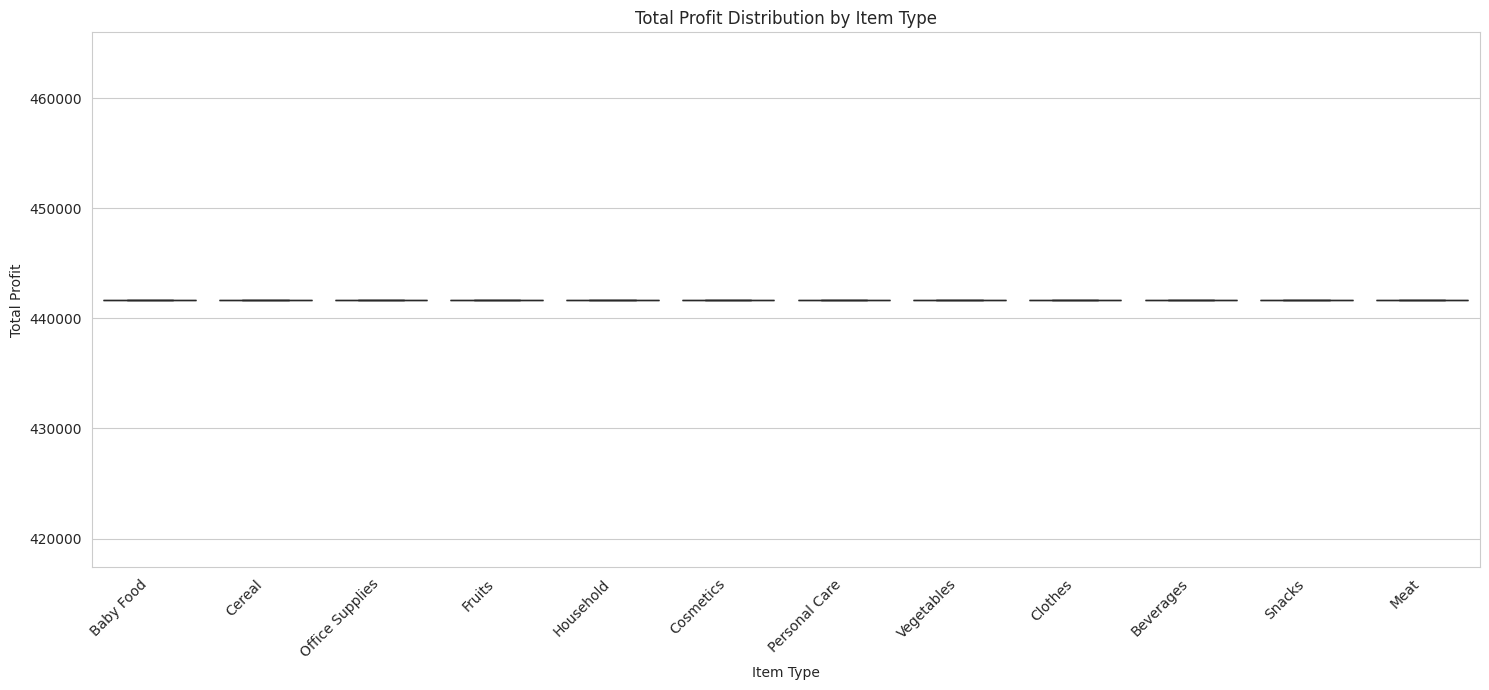

In [ ]:
# Boxplot for Total Profit by Item_Type
plt.figure(figsize=(15, 7))
sns.boxplot(x='Item_Type', y='Total Profit', data=merged_df, palette='viridis', hue='Item_Type', legend=False)
plt.title('Total Profit Distribution by Item Type')
plt.xlabel('Item Type')
plt.ylabel('Total Profit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Total Profit by Region

Let's analyze the total profit generated by each region to identify top-performing geographical areas.

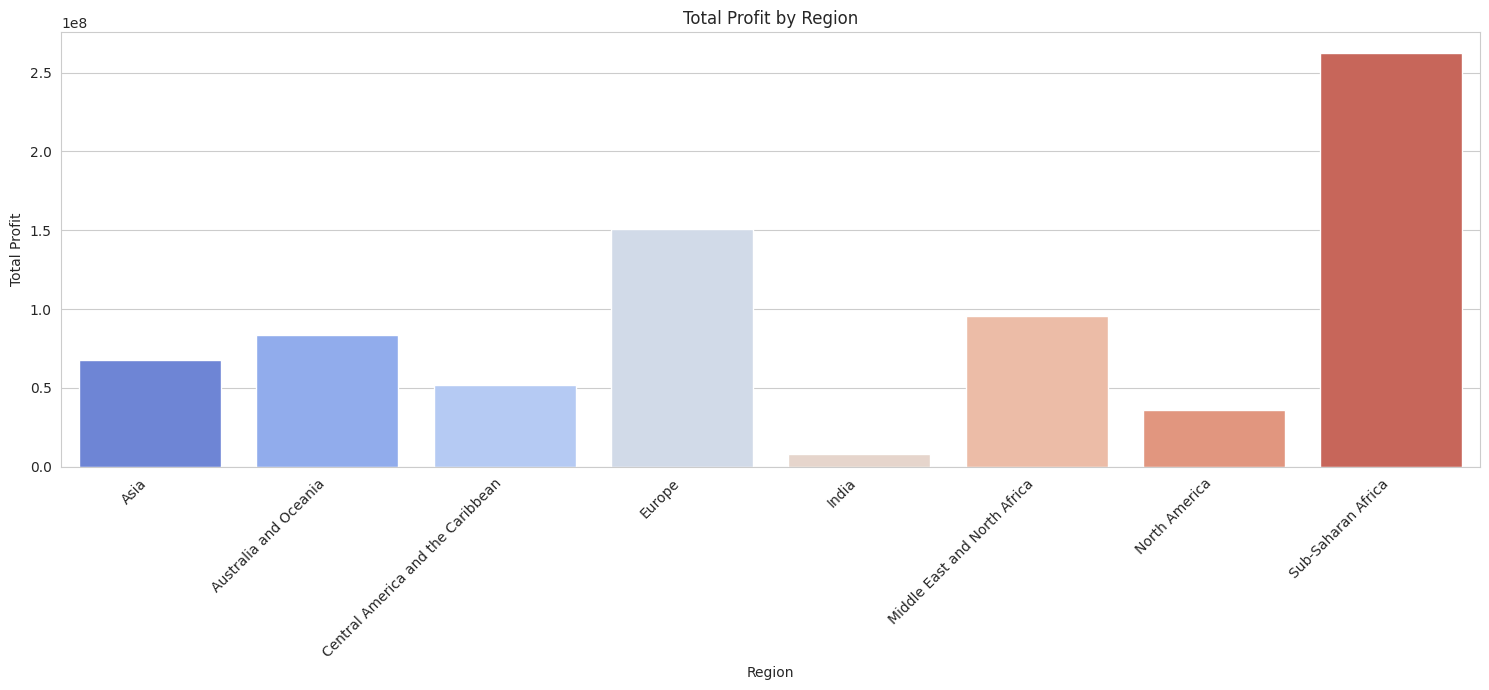

In [ ]:
plt.figure(figsize=(15, 7))
sns.barplot(x='Region', y='Total Profit', data=merged_df.groupby('Region')['Total Profit'].sum().reset_index(), palette='coolwarm', hue='Region', legend=False)
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Total Profit Spread by Sales Channel

Let's visualize the distribution and spread of 'Total Profit' for each 'Sales_Channel' using a violin plot.

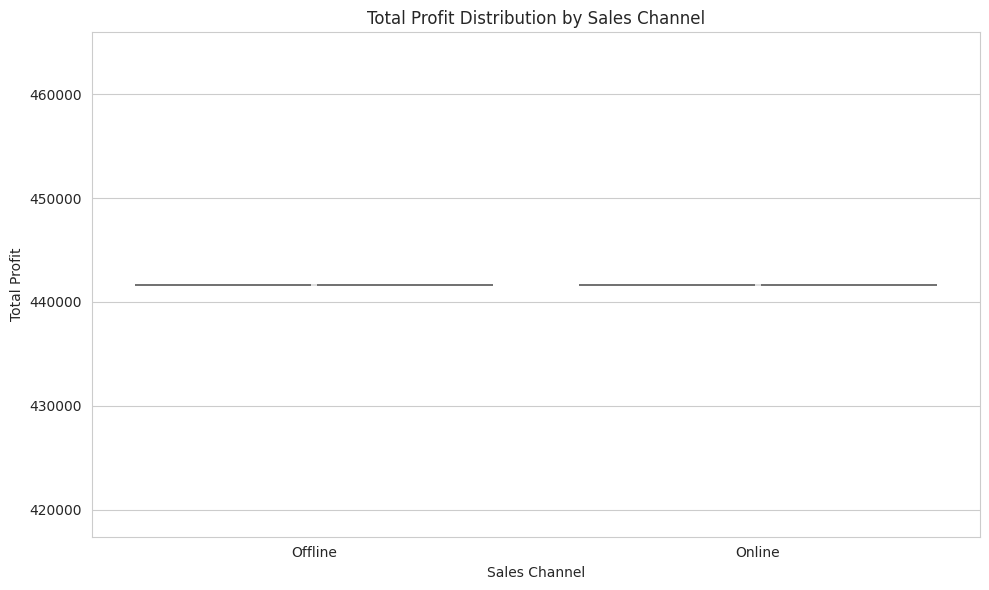

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Sales_Channel', y='Total Profit', data=merged_df, palette='pastel', hue='Sales_Channel', legend=False)
plt.title('Total Profit Distribution by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.show()

### Relationship between Total Revenue and Total Profit

Let's visualize the correlation between 'Total Revenue' and 'Total Profit' using a scatter plot.

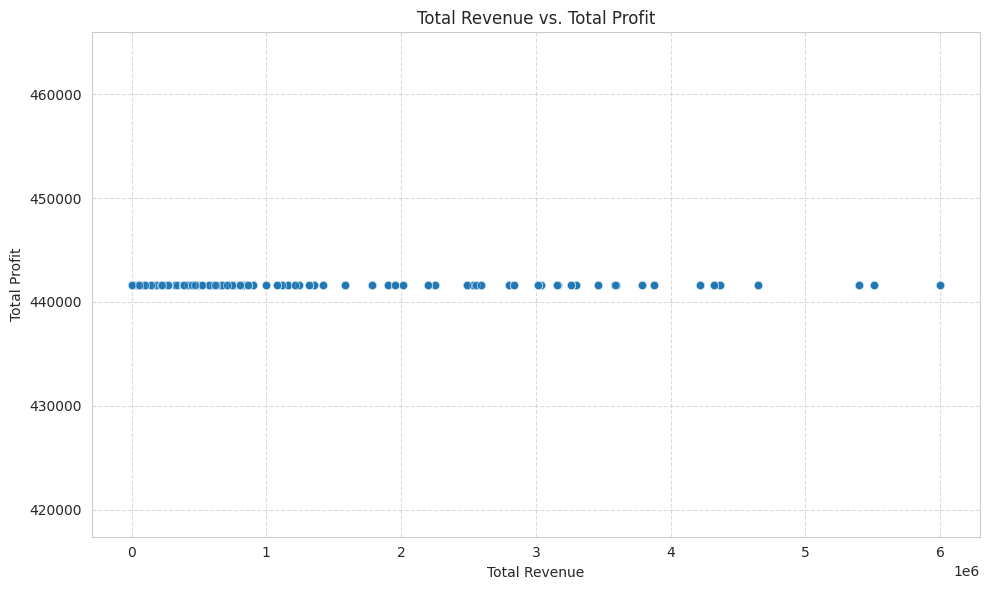

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Total_Revenue', y='Total Profit', data=merged_df, alpha=0.6)
plt.title('Total Revenue vs. Total Profit')
plt.xlabel('Total Revenue')
plt.ylabel('Total Profit')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()